In [34]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import yfinance as yf


In [58]:
from sklearn.preprocessing import MinMaxScaler

In [5]:
df = yf.download(
    "TSLA",
    start="2015-01-01",
    end="2025-12-31"
)

display(df.head())

/tmp/ipykernel_11830/2227932867.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2015-01-02,14.620667,14.883333,14.217333,14.858000,71466000
2015-01-05,14.006000,14.433333,13.810667,14.303333,80527500
2015-01-06,14.085333,14.280000,13.614000,14.004000,93928500
2015-01-07,14.063333,14.318667,13.985333,14.223333,44526000
2015-01-08,14.041333,14.253333,14.000667,14.187333,51637500


In [46]:
#Graficas
def plotTimeSeries(dataframe, column, title, plotType='line', startDate=None, endDate=None, xLabel='Fecha', yLabel='Valor', figureSize=(14, 6)):

    filteredData = dataframe.copy()

    if startDate is not None:
        filteredData = filteredData[filteredData.index >= startDate]

    if endDate is not None:
        filteredData = filteredData[filteredData.index <= endDate]

    seriesData = filteredData[column].squeeze()

    plt.figure(figsize=figureSize)

    if plotType == 'line':
        plt.plot(filteredData.index, seriesData)

    elif plotType == 'bar':
        plt.bar(filteredData.index, seriesData)

    plt.title(title)
    plt.xlabel(xLabel)
    plt.ylabel(yLabel)
    plt.grid(True)

    plt.show()

In [65]:
def createTimeSeries(caracteristicasData, targetData, sequenceLength=30):

    X = []
    y = []

    for i in range(sequenceLength, len(caracteristicasData)):

        X.append(caracteristicasData[i-sequenceLength:i])
        y.append(targetData[i])

    return np.array(X), np.array(y)

In [75]:
def createTimeSeriesBatches(caracteristicasData, targetData, sequenceLength=30, batchSize=32):

    X, y = createTimeSeries(caracteristicasData=caracteristicasData, targetData=targetData, sequenceLength=sequenceLength)

    XBatches = []
    yBatches = []

    for i in range(0, len(X), batchSize):

        XBatches.append(X[i:i+batchSize])
        yBatches.append(y[i:i+batchSize])

    return XBatches, yBatches

In [35]:
print("\nValores faltantes:")
print(df.isnull().sum())
print("\nDuplicados:")
print(df.duplicated().sum())

df.drop_duplicates(inplace=True)
df.dropna(inplace=True)


Valores faltantes:
Price   Ticker
Close   TSLA      0
High    TSLA      0
Low     TSLA      0
Open    TSLA      0
Volume  TSLA      0
dtype: int64

Duplicados:
0


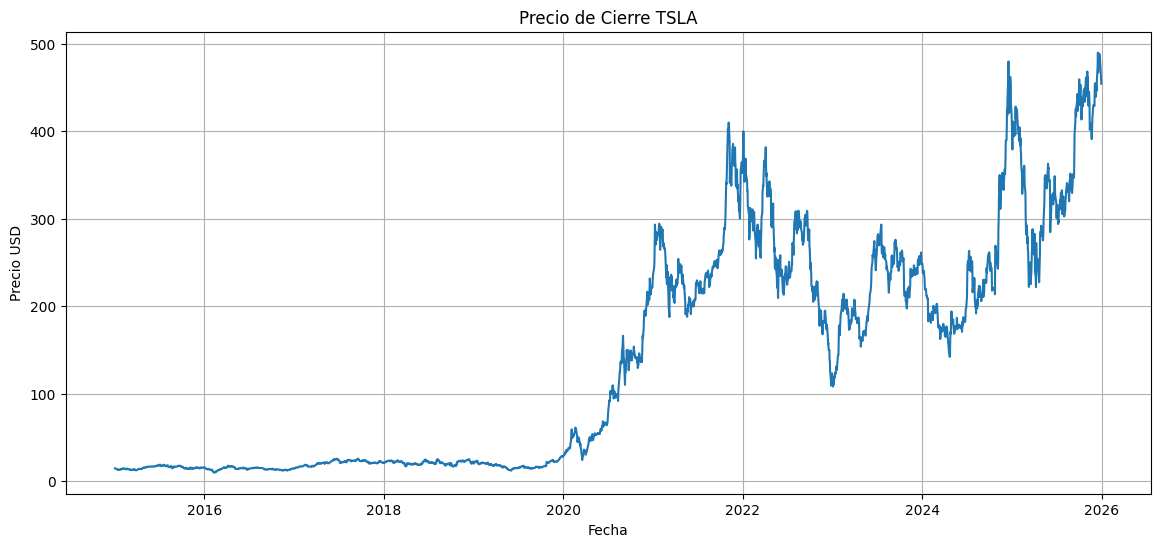

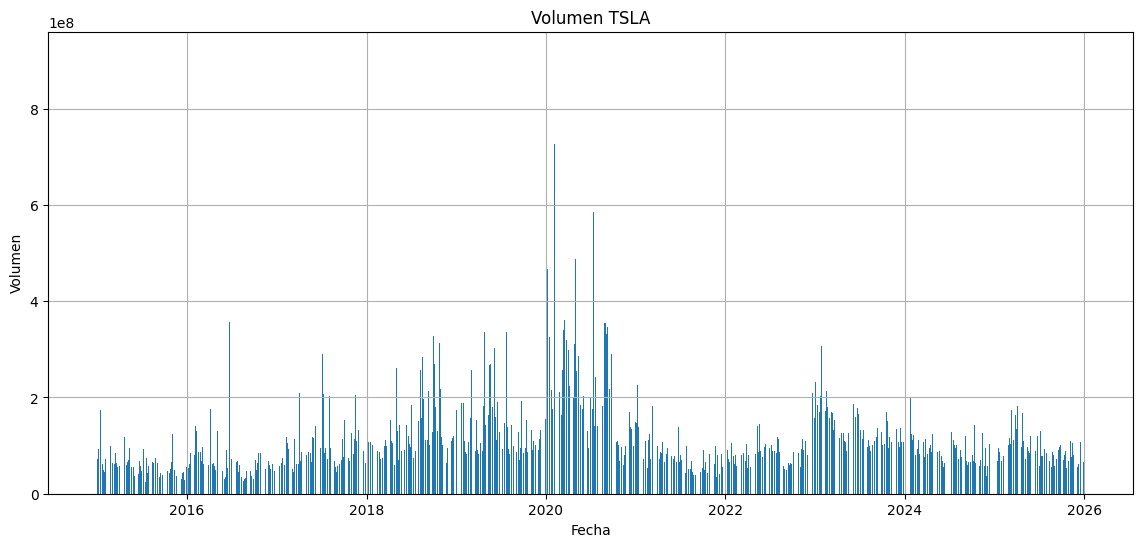

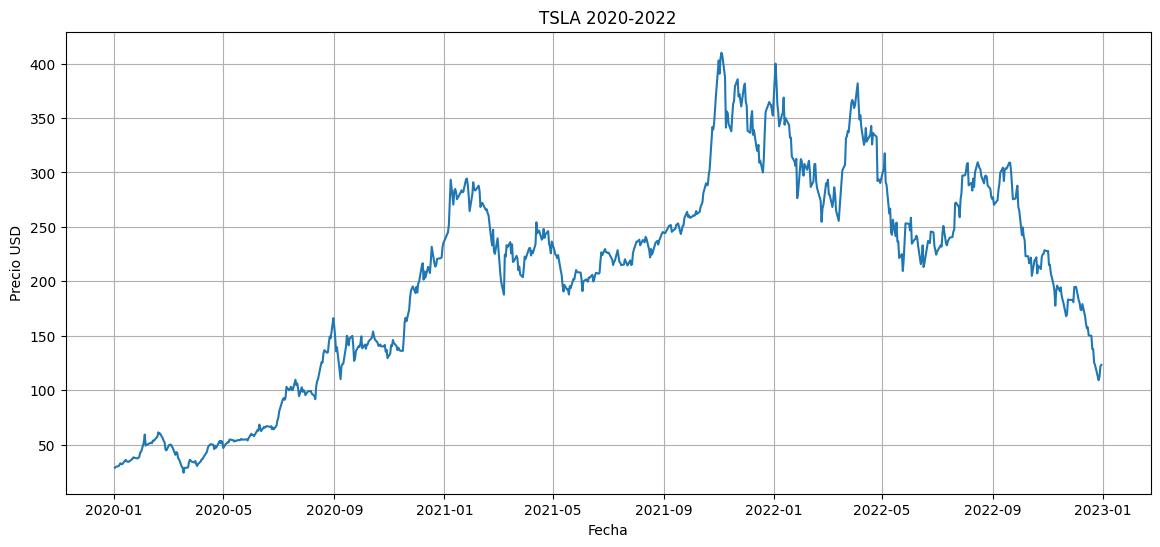

In [49]:
plotTimeSeries( dataframe=df,column='Close',title='Precio de Cierre TSLA',plotType='line',yLabel='Precio USD')
plotTimeSeries(dataframe=df,column='Volume',title='Volumen TSLA',plotType='bar',yLabel='Volumen')
plotTimeSeries(dataframe=df,column='Close',title='TSLA 2020-2022',plotType='line',startDate='2020-01-01',endDate='2022-12-31',yLabel='Precio USD')



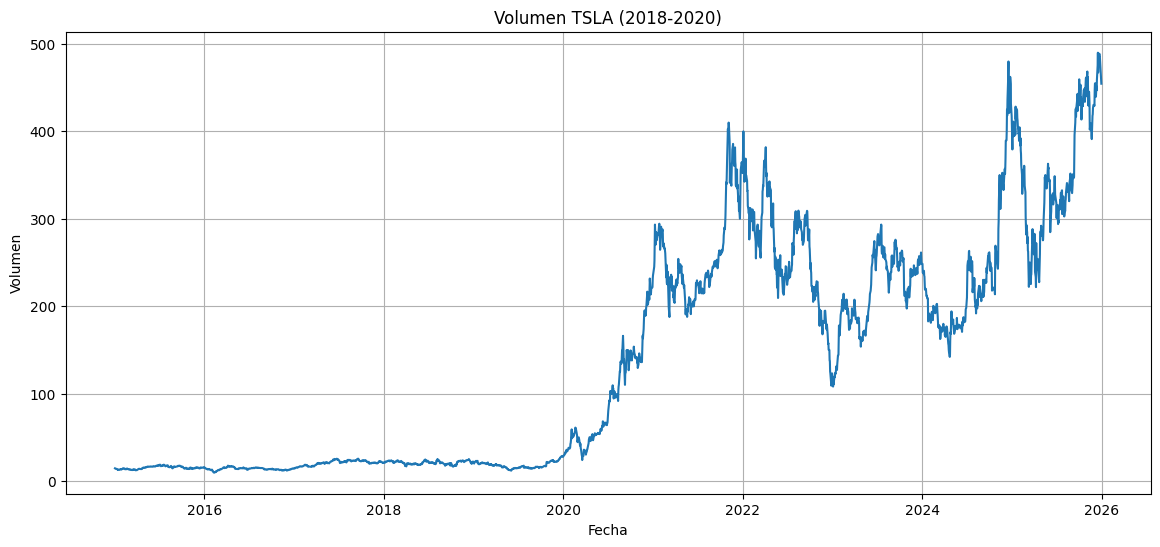

In [17]:
plotTimeSeries(dataframe=df,column='Close',title='Volumen TSLA (2018-2020)',startDate=None,endDate=None,yLabel='Volumen')

In [36]:
print("\nEstadísticas descriptivas:")
print(df.describe())


Estadísticas descriptivas:
Price         Close         High          Low         Open        Volume
Ticker         TSLA         TSLA         TSLA         TSLA          TSLA
count   2765.000000  2765.000000  2765.000000  2765.000000  2.765000e+03
mean     137.375190   140.420256   134.183493   137.400250  1.110144e+08
std      130.645336   133.575996   127.620236   130.736915  7.152517e+07
min        9.578000    10.331333     9.403333     9.488000  1.062000e+07
25%       17.844667    18.072666    17.544001    17.825333  6.772660e+07
50%       71.987335    72.512665    66.915337    67.518669  9.286200e+07
75%      241.029999   247.000000   236.449997   241.809998  1.284645e+08
max      489.880005   498.829987   485.329987   489.880005  9.140820e+08


In [54]:
print('Valor inicial df:',df.index.min())
print('valor final df  :',df.index.max())
print('Columnas df     :',df.columns)

Valor inicial df: 2015-01-02 00:00:00
valor final df  : 2025-12-30 00:00:00
Columnas df     : MultiIndex([( 'Close', 'TSLA'),
            (  'High', 'TSLA'),
            (   'Low', 'TSLA'),
            (  'Open', 'TSLA'),
            ('Volume', 'TSLA')],
           names=['Price', 'Ticker'])


In [56]:
caracteristicas  = [ 'Open','High','Low','Close','Volume']

data = df[caracteristicas].copy()


data['SubeBaja'] = np.where(data['Close'].shift(-1) > data['Close'],1,0)
data.dropna(inplace=True)
print(data)

Price             Open        High         Low       Close    Volume SubeBaja
Ticker            TSLA        TSLA        TSLA        TSLA      TSLA         
Date                                                                         
2015-01-02   14.858000   14.883333   14.217333   14.620667  71466000        0
2015-01-05   14.303333   14.433333   13.810667   14.006000  80527500        1
2015-01-06   14.004000   14.280000   13.614000   14.085333  93928500        0
2015-01-07   14.223333   14.318667   13.985333   14.063333  44526000        0
2015-01-08   14.187333   14.253333   14.000667   14.041333  51637500        0
...                ...         ...         ...         ...       ...      ...
2025-12-23  489.399994  491.970001  482.839996  485.559998  58223600        0
2025-12-24  488.480011  490.899994  476.799988  485.399994  41285400        0
2025-12-26  485.230011  489.089996  473.820007  475.190002  58780700        0
2025-12-29  469.000000  469.399994  459.000000  459.640015  6626

In [66]:
scaler = MinMaxScaler(feature_range=(0,1))

caracteristicasEscaladas = scaler.fit_transform(data[caracteristicas])

In [68]:
X, y = createTimeSeries(caracteristicasData=caracteristicasEscaladas, targetData=data['SubeBaja'].values, sequenceLength=30)
print(X.shape)
print(y.shape)

(2735, 30, 5)
(2735,)


In [72]:
# print(X[0])


In [76]:
XBatches, yBatches = createTimeSeriesBatches(caracteristicasData=caracteristicasEscaladas, targetData=data['SubeBaja'].values, sequenceLength=30, batchSize=32)

print(len(XBatches))
print(XBatches[0].shape)
print(yBatches[0].shape)

86
(32, 30, 5)
(32,)


In [77]:
def plotBatchTargetDistribution(yBatch, title='Distribución Batch'):

    values, counts = np.unique(yBatch,return_counts=True)
    plt.figure(figsize=(6,4))
    plt.bar(values.astype(str), counts)
    plt.title(title)
    plt.xlabel('Clase')
    plt.ylabel('Cantidad')
    plt.grid(True)
    plt.show()

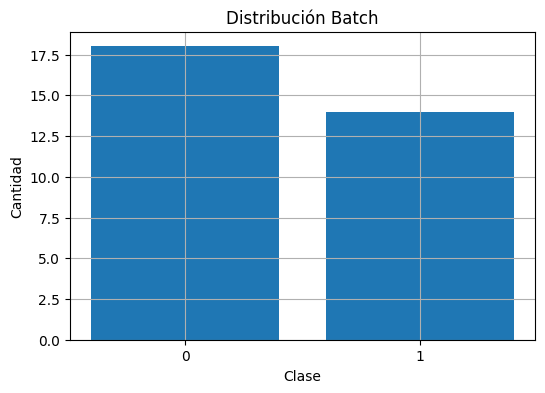

In [78]:
plotBatchTargetDistribution(yBatches[0])

In [84]:
def plotHistogram(data, title):

    plt.figure(figsize=(8,5))
    plt.hist(data, bins=30)
    plt.title(title)
    plt.grid(True)
    plt.show()

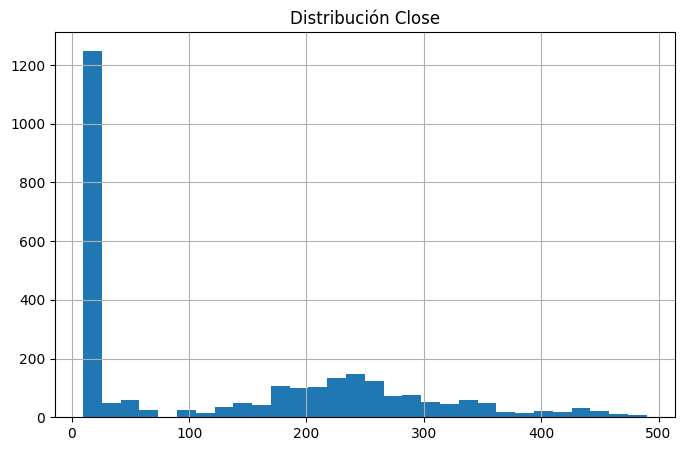

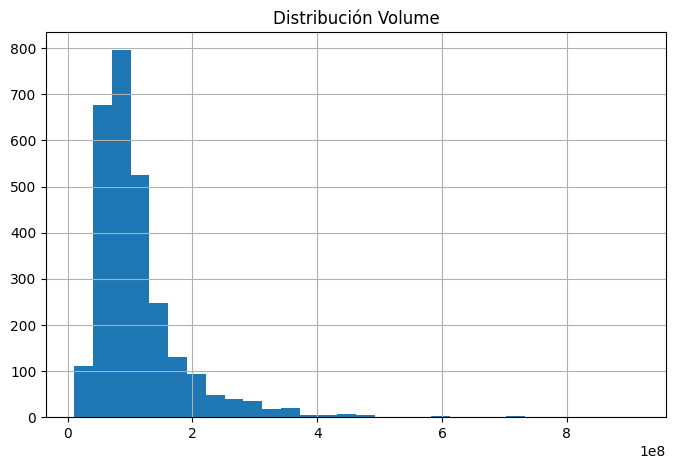

In [87]:
plotHistogram(data['Close'],'Distribución Close')
plotHistogram(data['Volume'],'Distribución Volume')

Como era de esperarse por ser series financieras de acciones los datos No son gauseanos y tiene cola pesadas y volatilidad agrupada.

In [92]:
def plotDensity(data, title, figureSize=(8,5)):
    seriesData = np.array(data).squeeze()
    pd.Series(seriesData).plot(kind='density',figsize=figureSize)
    plt.title(title)
    plt.grid(True)
    plt.show()

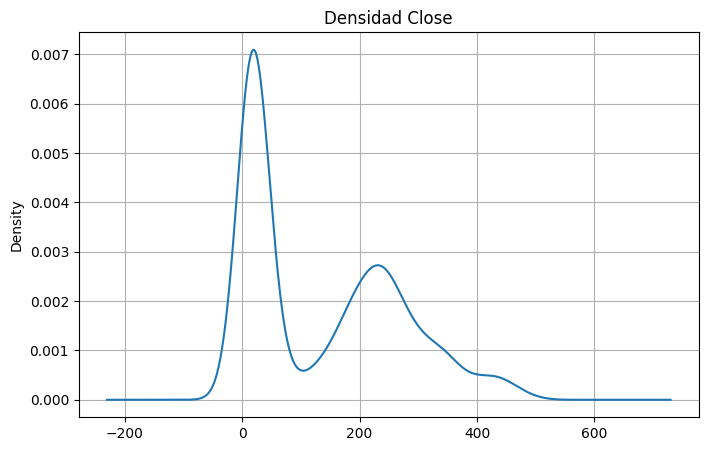

In [94]:
plotDensity(data['Close'],'Densidad Close')

Valores posibles del precio X y la densidad relativa de esos valores en y. Entonces aca podemos visualizar donde se concentran los precios.